# P300 Speller完整实验主线（交接版）

本Notebook省略数据质量检查，保留从原始Excel读取、初始ERP展示、主/备选预处理、P300时间区间选择、传统机器学习比较和基础模型选择的完整代码。默认沿主预处理方案继续：`0.5–30 Hz → 125 Hz → [-200,0) ms baseline`。

未知测试trial不参与窗口选择、超参数选择或模型比较。EEGNet因训练机制和运行依赖不同，已拆分至独立Notebook。

## 1. 原始数据读取与统一配置

In [1]:
from __future__ import annotations
import json, platform, sys, warnings
from dataclasses import dataclass
from pathlib import Path
import matplotlib as mpl
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import scipy
from IPython.display import display
from scipy.signal import butter, sosfiltfilt, resample_poly, welch

warnings.filterwarnings("ignore", category=RuntimeWarning)
PROJECT_ROOT = Path.cwd().resolve().parent if Path.cwd().name == "全流程" else Path.cwd().resolve()
FLOW_ROOT = PROJECT_ROOT / "全流程"
DATA_DIR = PROJECT_ROOT / "P300-S1"
OUTPUT_DIR = FLOW_ROOT / "outputs" / "02_preprocessing"
TABLE_DIR, FIGURE_DIR, DATA_OUT = OUTPUT_DIR/"tables", OUTPUT_DIR/"figures", OUTPUT_DIR/"data"
for p in (TABLE_DIR, FIGURE_DIR, DATA_OUT): p.mkdir(parents=True, exist_ok=True)

FS_RAW = 250
N_CHANNELS = 20
CHANNELS = [f"Ch{i:02d}" for i in range(1, 21)]
VALID_EVENTS, ROUND_END = set(range(1,13)), 100
EPOCH_TMIN, EPOCH_TMAX = -0.2, 0.8
FILTER_BAND = (0.5, 30.0)
MATRIX = np.array(list("ABCDEFGHIJKLMNOPQRSTUVWXYZ1234567890")).reshape(6,6)
SCHEMES = {
    "main_125Hz_B200": {"fs": 125, "baseline_ms": (-200, 0), "role": "main"},
    "alt_250Hz_B200": {"fs": 250, "baseline_ms": (-200, 0), "role": "supplement"},
    "alt_125Hz_B100": {"fs": 125, "baseline_ms": (-100, 0), "role": "supplement"},
    "alt_250Hz_B100": {"fs": 250, "baseline_ms": (-100, 0), "role": "supplement"},
}
COL = {"raw":"#8795A1", "filtered":"#2F6F8F", "main":"#C35D56", "alt1":"#3D8B84",
       "alt2":"#D8A441", "alt3":"#6077A8", "target":"#C35D56", "non":"#32739A"}
BAR_PALETTE = ["#315B7D", "#3F7896", "#4D969B", "#69AAA0", "#D2A447", "#B87B52"]
mpl.rcParams.update({
    "figure.dpi":120, "savefig.dpi":300, "savefig.bbox":"tight", "savefig.facecolor":"white",
    "font.family":"sans-serif", "font.sans-serif":["Microsoft YaHei","SimHei","DejaVu Sans"],
    "axes.unicode_minus":False, "axes.spines.top":False, "axes.spines.right":False,
    "axes.labelsize":10, "xtick.labelsize":9, "ytick.labelsize":9, "legend.frameon":False,
    "grid.color":"#DCE3E8", "grid.alpha":.65, "grid.linewidth":.7,
})
def savefig(fig, name):
    for ax in fig.axes:
        if ax.get_ylabel():
            ax.yaxis.label.set_rotation(0)
            ax.yaxis.label.set_verticalalignment("center")
            ax.yaxis.labelpad = 24
    fig.savefig(FIGURE_DIR/f"{name}_对话1.png",facecolor="white",transparent=False)
    plt.show(); plt.close(fig)
def vertical_label(text):
    # 每个汉字保持正向，整体按从上到下的竖列排列。
    return "\n".join(text)
def frame_panels(axes, labels=None, captions=None):
    axes=np.atleast_1d(axes).ravel()
    labels=labels or [chr(97+i) for i in range(len(axes))]
    captions=captions or [None]*len(axes)
    for ax,label,caption in zip(axes,labels,captions):
        for spine in ax.spines.values():
            spine.set_visible(True); spine.set_color("#111111"); spine.set_linewidth(1.0)
        panel_text=f"({label})" if caption is None else f"({label})  {caption}"
        ax.text(.015,.985,panel_text,transform=ax.transAxes,ha="left",va="top",
                fontsize=10.5,fontweight="semibold",color="#111111")
print(DATA_DIR, OUTPUT_DIR, sep="\n")

D:\zky_work\脑认知\sy2\P300-S1
D:\zky_work\脑认知\sy2\全流程\outputs\02_preprocessing


In [2]:
@dataclass
class Trial:
    split: str; sheet: str; eeg: np.ndarray; events: pd.DataFrame
    target_char: str|None; target_row: int|None; target_col: int|None

def decode_target(code):
    idx=int(code)-101
    if not 0<=idx<36: return None,None,None
    r,c=divmod(idx,6); return MATRIX[r,c],r+1,c+7

def load_split(split):
    db=pd.read_excel(DATA_DIR/f"S1_{split}_data.xlsx",sheet_name=None,header=None,engine="openpyxl")
    eb=pd.read_excel(DATA_DIR/f"S1_{split}_event.xlsx",sheet_name=None,header=None,engine="openpyxl")
    out=[]
    for sheet in db:
        if sheet not in eb: continue
        eeg=db[sheet].dropna(how="all").dropna(axis=1,how="all").to_numpy(float)
        ev=eb[sheet].dropna(how="all").dropna(axis=1,how="all").iloc[:,:2]
        ev.columns=["event_id","sample"]
        ev=ev.apply(pd.to_numeric,errors="coerce").dropna().astype(int).reset_index(drop=True)
        if eeg.size==0 or ev.empty: continue
        char,row,col=decode_target(ev.iloc[0,0])
        out.append(Trial(split,sheet,eeg,ev,char,row,col))
    return out

trials=load_split("train")+load_split("test")
sos=butter(4,FILTER_BAND,btype="bandpass",fs=FS_RAW,output="sos")
raw_epochs, filtered_epochs, rows=[],[],[]
n_pre,n_post=int(-EPOCH_TMIN*FS_RAW),int(EPOCH_TMAX*FS_RAW)
for trial_id,t in enumerate(trials):
    filtered=sosfiltfilt(sos,t.eeg,axis=0)
    round_no,pos=1,0
    for _,e in t.events.iloc[1:].iterrows():
        eid,onset=int(e["event_id"]),int(e["sample"])
        if eid==ROUND_END: round_no+=1; pos=0; continue
        if eid not in VALID_EVENTS: continue
        pos+=1; start,stop=onset-n_pre,onset+n_post
        if start<0 or stop>len(t.eeg): continue
        raw_epochs.append(t.eeg[start:stop]); filtered_epochs.append(filtered[start:stop])
        label=None if t.split=="test" else int(eid in [t.target_row,t.target_col])
        rows.append({"split":t.split,"trial_id":trial_id,"sheet":t.sheet,"round":round_no,
                     "position":pos,"event_id":eid,"onset_sample":onset,"label":label,
                     "target_char":t.target_char})
raw_epochs=np.stack(raw_epochs).astype(np.float32)
filtered_epochs=np.stack(filtered_epochs).astype(np.float32)
meta=pd.DataFrame(rows)
assert raw_epochs.shape==(1200,250,20)
assert np.isfinite(filtered_epochs).all()
meta.to_csv(TABLE_DIR/"epoch_metadata_对话1.csv",index=False,encoding="utf-8-sig")
display(meta.groupby(["split","label"],dropna=False).size().to_frame("n_epochs"))
print("raw/filtered:",raw_epochs.shape,filtered_epochs.shape)

n_epochs
split label          
test  NaN         480
train 0.0         600
      1.0         120

raw/filtered: (1200, 250, 20) (1200, 250, 20)


## 2. 初始数据展示

保留原01模块图5与图10的信息内容。图中滤波仅用于ERP展示，不参与后续方案选择；通道为匿名编号，不能解释为空间电极位置。

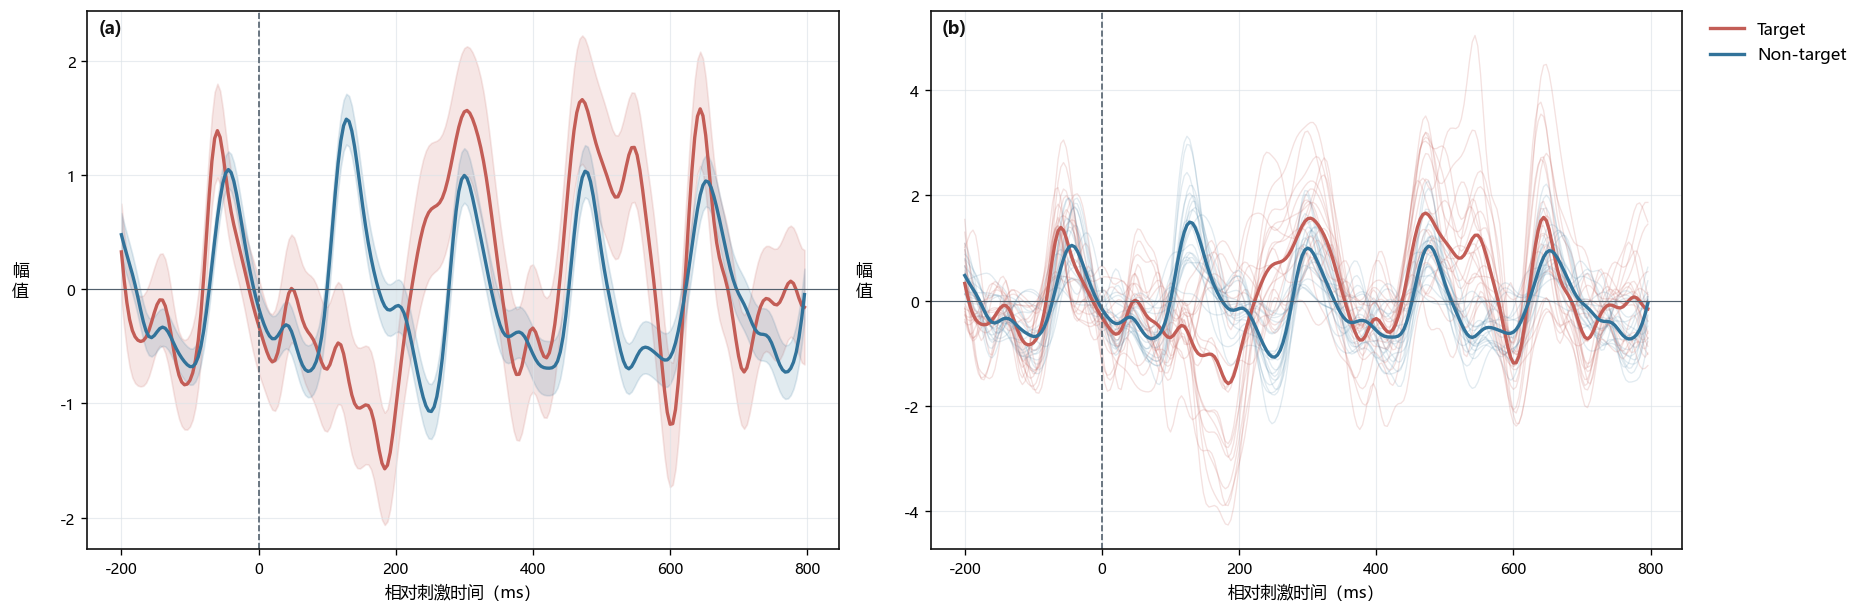

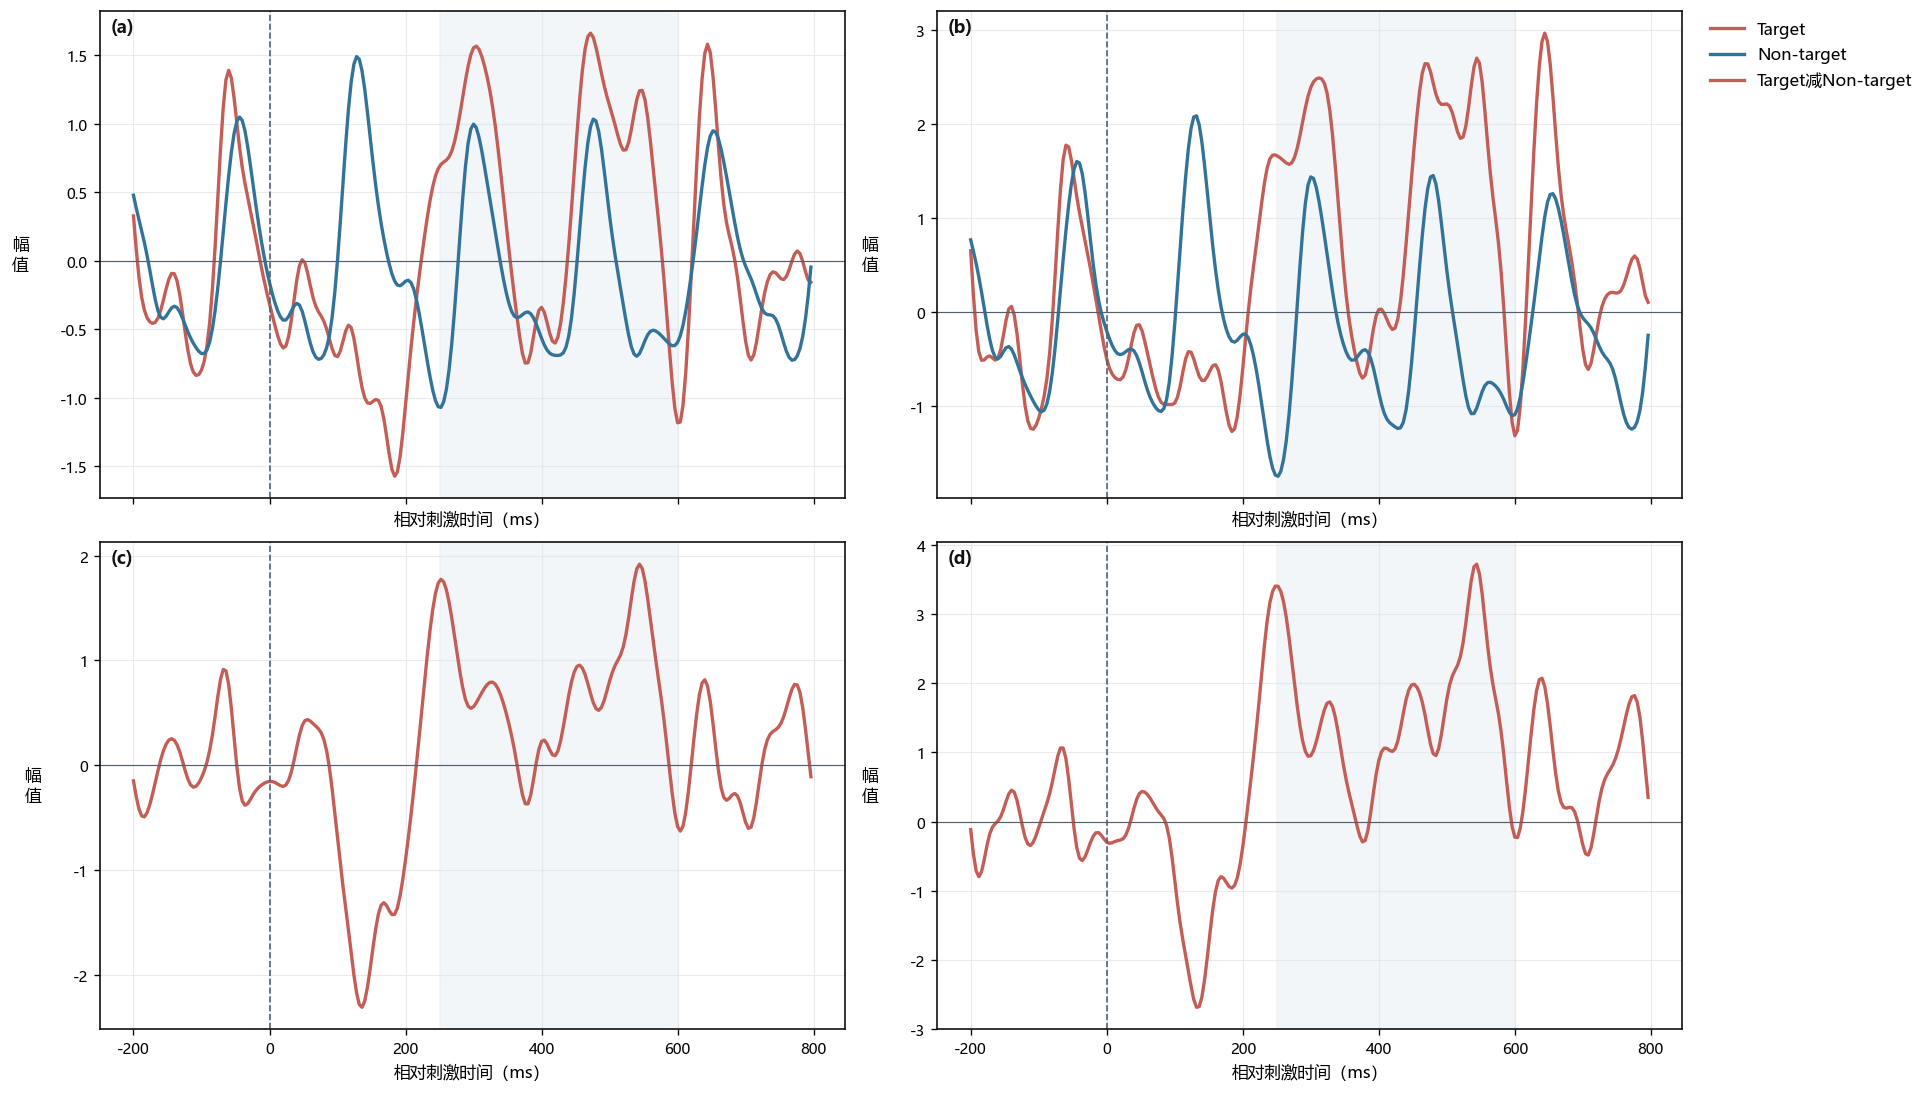

判别较强匿名通道: ['Ch08', 'Ch07', 'Ch02', 'Ch12', 'Ch20']


In [3]:
train_mask=(meta.split=="train").to_numpy(); target_mask=train_mask&(meta.label==1).to_numpy(); non_mask=train_mask&(meta.label==0).to_numpy()
display_epochs=filtered_epochs.copy()
t250=np.arange(display_epochs.shape[1])/FS_RAW+EPOCH_TMIN
bmask=(t250>=-.2)&(t250<0)
display_epochs-=display_epochs[:,bmask,:].mean(axis=1,keepdims=True)
tm=t250*1000

# 原01模块图5：全通道ERP与各匿名通道ERP。
fig,axes=plt.subplots(1,2,figsize=(14,5),constrained_layout=True)
tg=display_epochs[target_mask].mean(axis=2);ng=display_epochs[non_mask].mean(axis=2)
for arr,color,label in [(tg,COL["target"],"Target"),(ng,COL["non"],"Non-target")]:
    mean=arr.mean(0);sem=arr.std(0,ddof=1)/np.sqrt(len(arr));axes[0].plot(tm,mean,color=color,lw=2,label=label);axes[0].fill_between(tm,mean-sem,mean+sem,color=color,alpha=.15)
tc=display_epochs[target_mask].mean(0);nc=display_epochs[non_mask].mean(0)
for ch in range(20):axes[1].plot(tm,tc[:,ch],color=COL["target"],alpha=.18,lw=.8);axes[1].plot(tm,nc[:,ch],color=COL["non"],alpha=.14,lw=.8)
axes[1].plot(tm,tc.mean(1),color=COL["target"],lw=2,label="Target");axes[1].plot(tm,nc.mean(1),color=COL["non"],lw=2,label="Non-target")
for ax in axes:ax.axvline(0,color="#52606D",ls="--",lw=1);ax.axhline(0,color="#52606D",lw=.7);ax.set(xlabel="相对刺激时间（ms）",ylabel=vertical_label("幅值"));ax.grid(True)
handles,labels=axes[0].get_legend_handles_labels();fig.legend(handles,labels,loc="upper left",bbox_to_anchor=(1.005,1),ncol=1);frame_panels(axes)
savefig(fig,"交接版_01_initial_erp_fig05")

# 原01模块图10：全通道/差异波及判别较强匿名通道的四图展示。
diff=tc-nc;window=(tm>=250)&(tm<=600);rank=np.argsort(diff[window].mean(0))[::-1];top=rank[:5]
fig,axes=plt.subplots(2,2,figsize=(14,9),constrained_layout=True,sharex=True)
axes[0,0].plot(tm,tg.mean(0),color=COL["target"],lw=2,label="Target");axes[0,0].plot(tm,ng.mean(0),color=COL["non"],lw=2,label="Non-target")
axes[1,0].plot(tm,tg.mean(0)-ng.mean(0),color=COL["main"],lw=2,label="Target减Non-target")
axes[0,1].plot(tm,tc[:,top].mean(1),color=COL["target"],lw=2,label="Target");axes[0,1].plot(tm,nc[:,top].mean(1),color=COL["non"],lw=2,label="Non-target")
axes[1,1].plot(tm,diff[:,top].mean(1),color=COL["main"],lw=2,label="Target减Non-target")
for ax in axes.flat:ax.axvline(0,color="#52606D",ls="--",lw=1);ax.axhline(0,color="#52606D",lw=.7);ax.axvspan(250,600,color="#E8EEF3",alpha=.5);ax.set(xlabel="相对刺激时间（ms）",ylabel=vertical_label("幅值"));ax.grid(True)
handles=[];labels=[]
for ax in axes.flat:
    for h,l in zip(*ax.get_legend_handles_labels()):
        if l not in labels:handles.append(h);labels.append(l)
fig.legend(handles,labels,loc="upper left",bbox_to_anchor=(1.005,1),ncol=1);frame_panels(axes)
savefig(fig,"交接版_02_p300_grand_average_fig10")
print("判别较强匿名通道:",[CHANNELS[i] for i in top])

## 3. 预处理：主方案与备选方案

In [4]:
def downsample_epochs(x, fs_out):
    if fs_out==FS_RAW: return x.copy()
    if fs_out==125: return resample_poly(x,up=1,down=2,axis=1).astype(np.float32)
    raise ValueError(fs_out)

def baseline_correct(x, fs, baseline_ms):
    times=np.arange(x.shape[1])/fs+EPOCH_TMIN
    mask=(times>=baseline_ms[0]/1000)&(times<baseline_ms[1]/1000)
    if not mask.any(): raise ValueError("baseline window has no samples")
    return (x-x[:,mask,:].mean(axis=1,keepdims=True)).astype(np.float32),times,mask

processed={}; scheme_rows=[]
for name,cfg in SCHEMES.items():
    ds=downsample_epochs(filtered_epochs,cfg["fs"])
    x,t,bmask=baseline_correct(ds,cfg["fs"],cfg["baseline_ms"])
    processed[name]={"epochs":x,"times":t,"baseline_mask":bmask,"config":cfg}
    residual=x[:,bmask,:].mean(axis=1)
    scheme_rows.append({"scheme":name,"role":cfg["role"],"sampling_rate_hz":cfg["fs"],
        "baseline_start_ms":cfg["baseline_ms"][0],"baseline_end_ms":cfg["baseline_ms"][1],
        "n_epochs":x.shape[0],"n_times":x.shape[1],"n_channels":x.shape[2],
        "baseline_residual_abs_mean":float(np.abs(residual).mean()),
        "finite_ratio":float(np.isfinite(x).mean())})
scheme_summary=pd.DataFrame(scheme_rows)
scheme_summary.to_csv(TABLE_DIR/"preprocessing_scheme_summary_对话1.csv",index=False,encoding="utf-8-sig")
display(scheme_summary)

,scheme,role,sampling_rate_hz,baseline_start_ms,baseline_end_ms,n_epochs,n_times,n_channels,baseline_residual_abs_mean,finite_ratio
0,main_125Hz_B200,main,125,-200,0,1200,125,20,2.702844e-07,1.0
1,alt_250Hz_B200,supplement,250,-200,0,1200,250,20,3.709833e-07,1.0
2,alt_125Hz_B100,supplement,125,-100,0,1200,125,20,2.497527e-07,1.0
3,alt_250Hz_B100,supplement,250,-100,0,1200,250,20,3.264716e-07,1.0


In [5]:
main=processed["main_125Hz_B200"]
np.savez_compressed(DATA_OUT/"epochs_main_125Hz_B200_对话1.npz",
                    epochs=main["epochs"],times_s=main["times"],channels=np.array(CHANNELS))
config={"filter":{"type":"Butterworth","order":4,"band_hz":list(FILTER_BAND),"phase":"zero-phase",
                  "applied_to":"continuous trial before epoching"},
        "epoch_window_s":[EPOCH_TMIN,EPOCH_TMAX],"raw_sampling_rate_hz":FS_RAW,
        "schemes":SCHEMES,"main_scheme":"main_125Hz_B200","channel_labels":CHANNELS}
with open(OUTPUT_DIR/"preprocessing_config_对话1.json","w",encoding="utf-8") as f:
    json.dump(config,f,ensure_ascii=False,indent=2)
print(DATA_OUT/"epochs_main_125Hz_B200_对话1.npz")

D:\zky_work\脑认知\sy2\全流程\outputs\02_preprocessing\data\epochs_main_125Hz_B200_对话1.npz


### 3.1 预处理前后展示（原02模块图1）

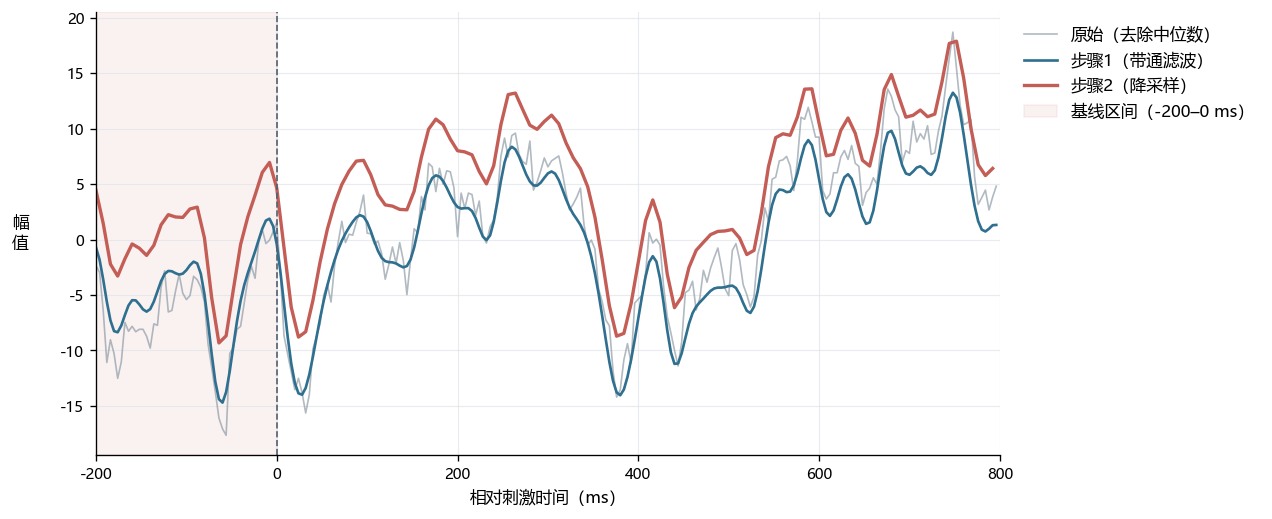

In [6]:
idx=int(np.where((meta.split=="train")&(meta.label==1))[0][0]); ch=0
t_raw=np.arange(250)/FS_RAW+EPOCH_TMIN
fig,ax=plt.subplots(figsize=(11.5,4.8))
raw_for_plot=raw_epochs[idx,:,ch]-np.median(raw_epochs[idx,:,ch])
ax.plot(t_raw*1000,raw_for_plot,color=COL["raw"],lw=1,alpha=.65,label="原始（去除中位数）")
ax.plot(t_raw*1000,filtered_epochs[idx,:,ch],color=COL["filtered"],lw=1.6,label="步骤1（带通滤波）")
ax.plot(main["times"]*1000,main["epochs"][idx,:,ch],color=COL["main"],lw=2,label="步骤2（降采样）")
ax.axvspan(-200,0,color=COL["main"],alpha=.08,label="基线区间（-200–0 ms）")
ax.axvline(0,color="#52606D",ls="--",lw=1)
ax.set(xlabel="相对刺激时间（ms）",ylabel=vertical_label("幅值"),xlim=(-200,800))
ax.grid(True); ax.legend(ncol=1,loc="upper left",bbox_to_anchor=(1.01,1.0))
fig.subplots_adjust(right=.78)
savefig(fig,"01_waveform_before_after")

主方案被显式赋给`main`，后续Notebook默认读取其压缩NPZ；备选方案保留用于消融，不根据未知测试集选择。

## 4. P300特征识别区间选择

In [7]:
from pathlib import Path
import json, warnings
import matplotlib as mpl
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from IPython.display import display
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis
from sklearn.metrics import average_precision_score,balanced_accuracy_score,roc_auc_score
from sklearn.model_selection import GroupKFold,LeaveOneGroupOut

warnings.filterwarnings("ignore")
ROOT=Path.cwd().resolve().parent if Path.cwd().name=="全流程" else Path.cwd().resolve()
FLOW=ROOT/"全流程"; INPUT=FLOW/"outputs"/"02_preprocessing"
OUT=FLOW/"outputs"/"04_time_window_selection"; TABLE=OUT/"tables"; FIG=OUT/"figures"
for p in (TABLE,FIG):p.mkdir(parents=True,exist_ok=True)
z=np.load(INPUT/"data"/"epochs_main_125Hz_B200_对话1.npz")
epochs=z["epochs"].astype(np.float32);times=z["times_s"]
meta=pd.read_csv(INPUT/"tables"/"epoch_metadata_对话1.csv")
mask=meta.split.eq("train").to_numpy();X=epochs[mask].transpose(0,2,1);m=meta.loc[mask].reset_index(drop=True)
y=m.label.astype(int).to_numpy();groups=m.trial_id.to_numpy();MATRIX=np.array(list("ABCDEFGHIJKLMNOPQRSTUVWXYZ1234567890")).reshape(6,6)
WINDOWS={"参考 0–800 ms":(0,.8),"候选 0–480 ms":(0,.48),"候选 100–600 ms":(.1,.6),"候选 200–400 ms":(.2,.4)}
SHRINKAGES=["auto",.05,.1,.2,.3,.5]
COLORS=["#8795A1","#315B7D","#4D969B","#D2A447"]
mpl.rcParams.update({"figure.dpi":120,"savefig.dpi":300,"savefig.bbox":"tight","font.family":"sans-serif",
 "font.sans-serif":["Microsoft YaHei","SimHei","DejaVu Sans"],"axes.unicode_minus":False,"axes.spines.top":False,
 "axes.spines.right":False,"grid.color":"#DCE3E8","grid.alpha":.65,"legend.frameon":False})
def vl(s):return "\n".join(s)
def decorate(axes):
    axes=np.atleast_1d(axes).ravel()
    for i,ax in enumerate(axes):
        if len(axes)>1:
            for sp in ax.spines.values():sp.set_visible(True);sp.set_color("#111");sp.set_linewidth(1)
            ax.text(.015,.985,f"({chr(97+i)})",transform=ax.transAxes,ha="left",va="top",fontweight="semibold")
        if ax.get_ylabel():ax.yaxis.label.set_rotation(0);ax.yaxis.labelpad=22
def save(fig,name):fig.savefig(FIG/f"{name}_对话1.png",facecolor="white",transparent=False);plt.show();plt.close(fig)
print(X.shape,np.bincount(y))

(720, 20, 125) [600 120]


In [8]:
def features(t0,t1):
    use=(times>=t0)&(times<t1);x=X[:,:,use]
    n_bins=max(1,int(round((t1-t0)/.025)));edges=np.linspace(0,x.shape[2],n_bins+1,dtype=int)
    return np.concatenate([x[:,:,edges[i]:edges[i+1]].mean(2) for i in range(n_bins)],axis=1)
def decode(scores,mm):
    f=mm[["trial_id","sheet","event_id","target_char"]].copy();f["score"]=scores;out=[]
    for tid,g in f.groupby("trial_id",sort=True):
        s=g.groupby("event_id").score.mean().reindex(range(1,13));r=int(s.iloc[:6].idxmax());c=int(s.iloc[6:].idxmax())
        out.append({"trial_id":tid,"sheet":g.sheet.iloc[0],"prediction":MATRIX[r-1,c-7],"target":g.target_char.iloc[0]})
    return pd.DataFrame(out)
def metrics(yy,score,mm):
    d=decode(score,mm)
    return {"balanced_accuracy":balanced_accuracy_score(yy,score>=0),"roc_auc":roc_auc_score(yy,score),
            "pr_auc":average_precision_score(yy,score),"character_accuracy":float((d.prediction==d.target).mean())}
feature_sets={name:features(*w) for name,w in WINDOWS.items()}
display(pd.DataFrame([{"window":n,"shape":str(x.shape),"features":x.shape[1]} for n,x in feature_sets.items()]))

,window,shape,features
0,参考 0–800 ms,"(720, 640)",640
1,候选 0–480 ms,"(720, 380)",380
2,候选 100–600 ms,"(720, 400)",400
3,候选 200–400 ms,"(720, 160)",160


In [9]:
logo=LeaveOneGroupOut();all_scores={};selection=[];predictions=[]
for window,Xf in feature_sets.items():
    oof=np.zeros(len(y))
    for fold,(tr,va) in enumerate(logo.split(Xf,y,groups),1):
        candidates=[]
        for sh in SHRINKAGES:
            ca,ap=[],[]
            for it,iv in GroupKFold(3).split(Xf[tr],y[tr],groups[tr]):
                model=LinearDiscriminantAnalysis(solver="lsqr",shrinkage=sh,priors=[.5,.5]).fit(Xf[tr][it],y[tr][it])
                sc=model.decision_function(Xf[tr][iv]);mm=m.iloc[tr[iv]].reset_index(drop=True)
                ca.append(metrics(y[tr][iv],sc,mm)["character_accuracy"]);ap.append(average_precision_score(y[tr][iv],sc))
            candidates.append((np.mean(ca),np.mean(ap),sh))
        best=max(candidates,key=lambda q:(q[0],q[1]))
        model=LinearDiscriminantAnalysis(solver="lsqr",shrinkage=best[2],priors=[.5,.5]).fit(Xf[tr],y[tr])
        oof[va]=model.decision_function(Xf[va])
        selection.append({"window":window,"outer_fold":fold,"held_out":m.iloc[va].sheet.iloc[0],
                          "selected_shrinkage":str(best[2]),"inner_character_accuracy":best[0],"inner_pr_auc":best[1]})
    all_scores[window]=oof;d=decode(oof,m);d["window"]=window;predictions.append(d)

rows=[]
for window,sc in all_scores.items():rows.append({"window":window,**metrics(y,sc,m),"n_features":feature_sets[window].shape[1]})
results=pd.DataFrame(rows).sort_values(["character_accuracy","pr_auc","balanced_accuracy"],ascending=False).reset_index(drop=True)
selection_df=pd.DataFrame(selection);pred_df=pd.concat(predictions,ignore_index=True)
results.to_csv(TABLE/"time_window_comparison_对话1.csv",index=False,encoding="utf-8-sig")
selection_df.to_csv(TABLE/"time_window_nested_selection_对话1.csv",index=False,encoding="utf-8-sig")
pred_df.to_csv(TABLE/"time_window_character_predictions_对话1.csv",index=False,encoding="utf-8-sig")
SELECTED=results.iloc[0].window
display(results);print("按预设规则选择:",SELECTED)

,window,balanced_accuracy,roc_auc,pr_auc,character_accuracy,n_features
0,候选 100–600 ms,0.714167,0.760861,0.445119,0.750000,400
1,参考 0–800 ms,0.697500,0.749611,0.438155,0.666667,640
2,候选 0–480 ms,0.705833,0.772944,0.450861,0.583333,380
3,候选 200–400 ms,0.627500,0.679056,0.315543,0.416667,160


按预设规则选择: 候选 100–600 ms


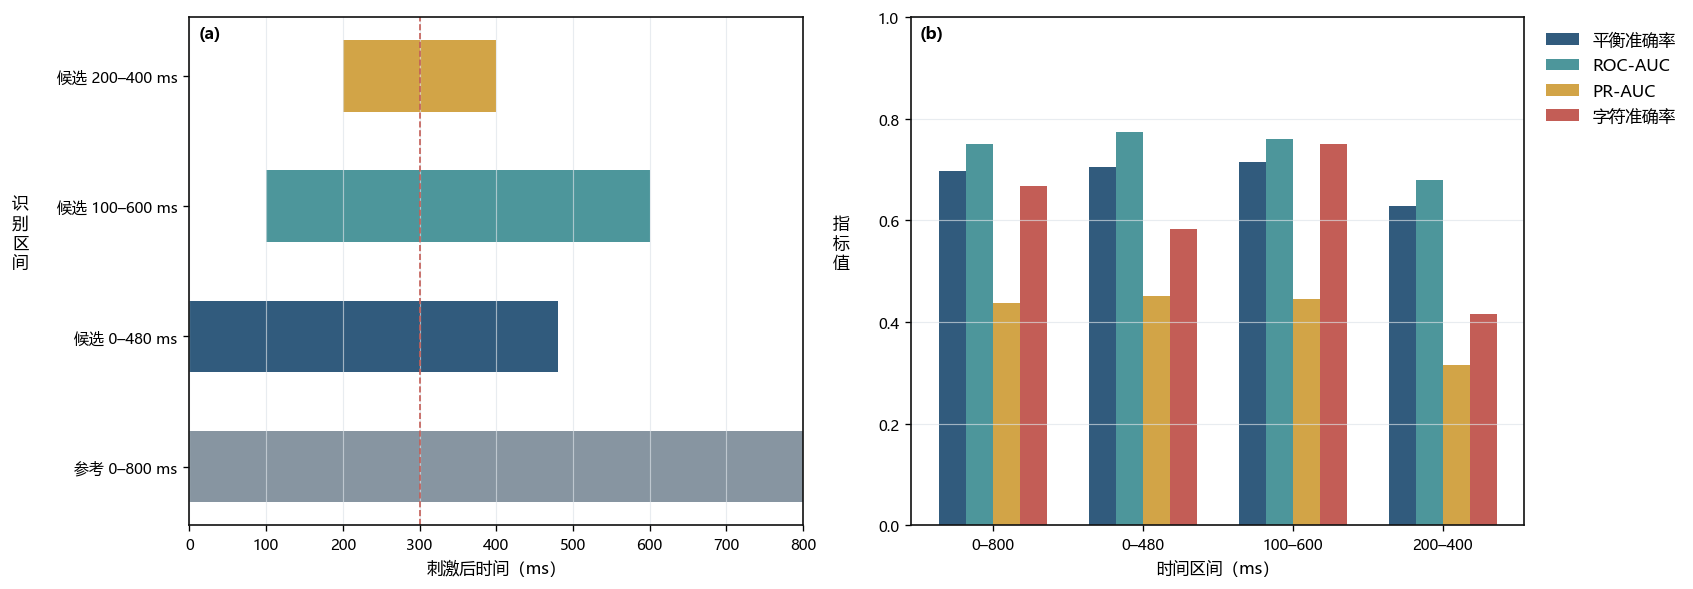

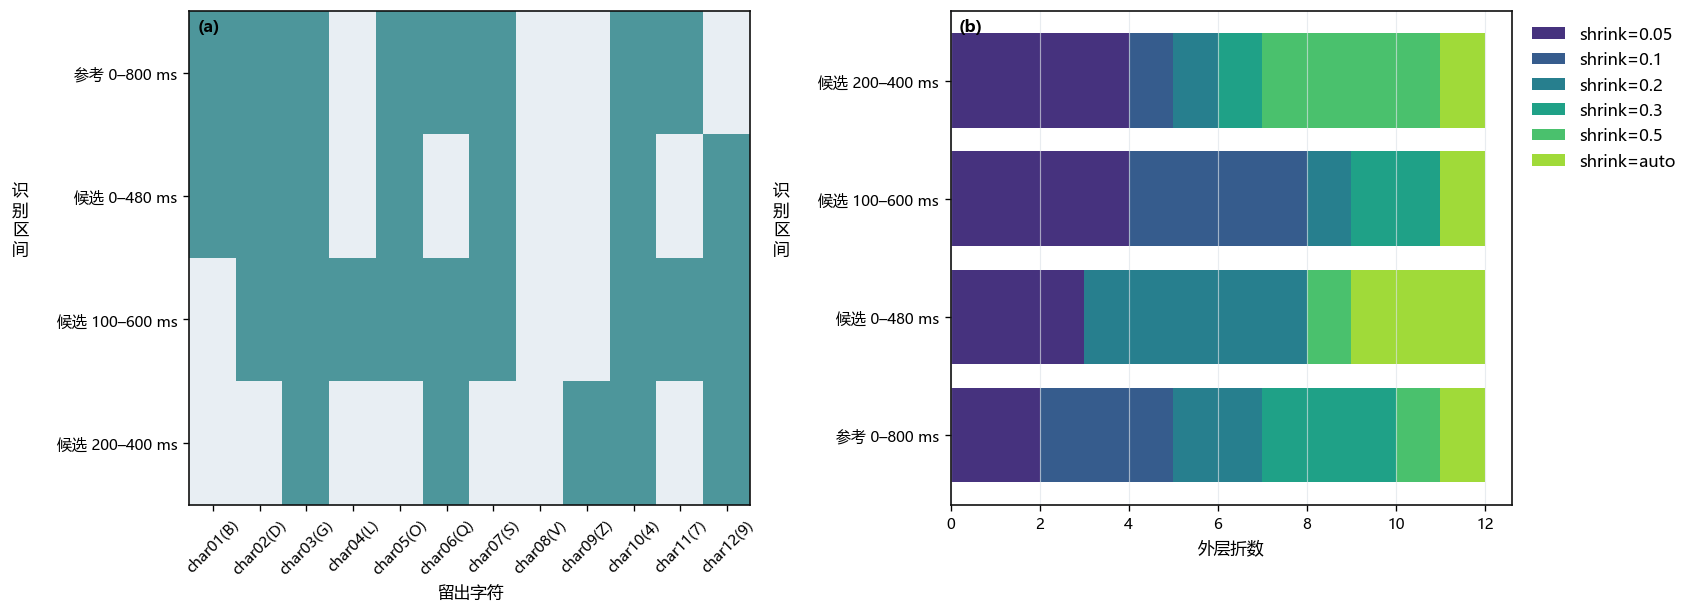

In [10]:
fig,axes=plt.subplots(1,2,figsize=(14,4.8),constrained_layout=True)
for i,(name,(a,b)) in enumerate(WINDOWS.items()):
    axes[0].barh(i,(b-a)*1000,left=a*1000,color=COLORS[i],height=.55,label=name)
axes[0].axvline(300,color="#C35D56",ls="--",lw=1);axes[0].set(xlabel="刺激后时间（ms）",ylabel=vl("识别区间"),yticks=range(4),yticklabels=list(WINDOWS),xlim=(0,800));axes[0].grid(axis="x")
r=results.set_index("window").reindex(WINDOWS)
x=np.arange(4);w=.18
for j,(metric,label) in enumerate([("balanced_accuracy","平衡准确率"),("roc_auc","ROC-AUC"),("pr_auc","PR-AUC"),("character_accuracy","字符准确率")]):
    axes[1].bar(x+(j-1.5)*w,r[metric],width=w,label=label,color=["#315B7D","#4D969B","#D2A447","#C35D56"][j])
axes[1].set(xticks=x,xticklabels=["0–800","0–480","100–600","200–400"],xlabel="时间区间（ms）",ylabel=vl("指标值"),ylim=(0,1));axes[1].grid(axis="y");axes[1].legend(loc="upper left",bbox_to_anchor=(1.01,1),ncol=1)
decorate(axes);save(fig,"01_time_windows_and_metrics")

fig,axes=plt.subplots(1,2,figsize=(14,5),constrained_layout=True)
pivot=pred_df.assign(correct=lambda d:d.prediction==d.target).pivot(index="window",columns="sheet",values="correct").reindex(WINDOWS).astype(int)
axes[0].imshow(pivot,cmap=mpl.colors.ListedColormap(["#E8EEF3","#4D969B"]),vmin=0,vmax=1,aspect="auto")
axes[0].set(xticks=range(12),xticklabels=pivot.columns,yticks=range(4),yticklabels=pivot.index,xlabel="留出字符",ylabel=vl("识别区间"));axes[0].tick_params(axis="x",rotation=45)
counts=selection_df.groupby(["window","selected_shrinkage"]).size().unstack(fill_value=0).reindex(WINDOWS)
bottom=np.zeros(4)
for i,col in enumerate(counts.columns):axes[1].barh(range(4),counts[col],left=bottom,label=f"shrink={col}",color=mpl.colormaps["viridis"]((i+1)/(len(counts.columns)+1)));bottom+=counts[col].to_numpy()
axes[1].set(xlabel="外层折数",ylabel=vl("识别区间"),yticks=range(4),yticklabels=counts.index);axes[1].grid(axis="x");axes[1].legend(loc="upper left",bbox_to_anchor=(1.01,1),ncol=1)
decorate(axes);save(fig,"02_character_correctness_and_parameters")

In [11]:
report={"selection_rule":"character_accuracy > PR-AUC > balanced_accuracy","selected_window":SELECTED,
        "windows_ms":{k:[int(a*1000),int(b*1000)] for k,(a,b) in WINDOWS.items()},"test_used":False,
        "results":results.to_dict(orient="records")}
with open(OUT/"time_window_selection_report_对话1.json","w",encoding="utf-8") as f:json.dump(report,f,ensure_ascii=False,indent=2)
display(pd.DataFrame([{"type":k,"file":p.name} for k,d in [("table",TABLE),("figure",FIG)] for p in sorted(d.glob("*_对话1.*"))]))

,type,file
0,table,time_window_character_predictions_对话1.csv
1,table,time_window_comparison_对话1.csv
2,table,time_window_nested_selection_对话1.csv
3,figure,01_time_windows_and_metrics_对话1.png
4,figure,02_character_correctness_and_parameters_对话1.png


## 5. 传统机器学习候选与文献依据

- P300分类器比较支持线性判别和线性SVM作为稳健基线：[Krusienski et al.](https://pubmed.ncbi.nlm.nih.gov/17124334/)
- xDAWN用于增强P300诱发响应：[Rivet et al.](https://pubmed.ncbi.nlm.nih.gov/19174332/)
- ERP协方差可在黎曼切空间中分类：[Barachant & Congedo](https://arxiv.org/abs/1409.0107)

比较Shrinkage LDA、Logistic Regression、Linear SVM、xDAWN+LDA与xDAWN+Riemannian Tangent Space。外层留一字符；普通线性模型在内层分组验证中调参。

In [12]:
from __future__ import annotations
import json, random, sys, time, warnings
from copy import deepcopy
from pathlib import Path
import matplotlib as mpl
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from IPython.display import display
from pyriemann.estimation import XdawnCovariances
from pyriemann.classification import TSClassifier
from sklearn.base import clone
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import average_precision_score, balanced_accuracy_score, roc_auc_score
from sklearn.model_selection import GroupKFold, LeaveOneGroupOut
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.svm import LinearSVC

warnings.filterwarnings("ignore")
SEED=20260711
random.seed(SEED); np.random.seed(SEED)
PROJECT_ROOT=Path.cwd().resolve().parent if Path.cwd().name=="全流程" else Path.cwd().resolve()
FLOW_ROOT=PROJECT_ROOT/"全流程"
INPUT_DIR=FLOW_ROOT/"outputs"/"02_preprocessing"
OUTPUT_DIR=FLOW_ROOT/"outputs"/"03_model_selection"
TABLE_DIR,FIGURE_DIR,MODEL_DIR=OUTPUT_DIR/"tables",OUTPUT_DIR/"figures",OUTPUT_DIR/"models"
for p in (TABLE_DIR,FIGURE_DIR,MODEL_DIR): p.mkdir(parents=True,exist_ok=True)

z=np.load(INPUT_DIR/"data"/"epochs_main_125Hz_B200_对话1.npz")
epochs=z["epochs"].astype(np.float32); times=z["times_s"]
meta=pd.read_csv(INPUT_DIR/"tables"/"epoch_metadata_对话1.csv")
mask=meta["split"].eq("train").to_numpy()
X_epoch=epochs[mask].transpose(0,2,1)  # N,C,T
meta_train=meta.loc[mask].reset_index(drop=True)
y=meta_train["label"].astype(int).to_numpy(); groups=meta_train["trial_id"].to_numpy()
assert X_epoch.shape==(720,20,125) and len(np.unique(groups))==12

COL={"blue":"#315B7D","teal":"#4D969B","gold":"#D2A447","coral":"#C35D56","gray":"#8795A1","green":"#4C8B70"}
PALETTE=["#315B7D","#3F7896","#4D969B","#69AAA0","#D2A447","#B87B52"]
mpl.rcParams.update({"figure.dpi":120,"savefig.dpi":300,"savefig.bbox":"tight","savefig.facecolor":"white",
 "font.family":"sans-serif","font.sans-serif":["Microsoft YaHei","SimHei","DejaVu Sans"],"axes.unicode_minus":False,
 "axes.spines.top":False,"axes.spines.right":False,"grid.color":"#DCE3E8","grid.alpha":.65,"legend.frameon":False})
def vlabel(s): return "\n".join(s)
def decorate(fig,axes,legend=False):
    axes=np.atleast_1d(axes).ravel()
    if len(axes)>1:
        for i,ax in enumerate(axes):
            for sp in ax.spines.values(): sp.set_visible(True);sp.set_color("#111");sp.set_linewidth(1)
            ax.text(.015,.985,f"({chr(97+i)})",transform=ax.transAxes,ha="left",va="top",fontweight="semibold")
    for ax in axes:
        if ax.get_ylabel(): ax.yaxis.label.set_rotation(0);ax.yaxis.labelpad=22
def savefig(fig,name): fig.savefig(FIGURE_DIR/f"{name}_对话1.png",facecolor="white",transparent=False);plt.show();plt.close(fig)
print(X_epoch.shape, np.bincount(y), np.unique(groups))

(720, 20, 125) [600 120] [ 0  1  2  3  4  5  6  7  8  9 10 11]


In [13]:
post=(times>=0)&(times<.8)
Xp=X_epoch[:,:,post]
n_bins=32
edges=np.linspace(0,Xp.shape[2],n_bins+1,dtype=int)
X_flat=np.concatenate([Xp[:,:,edges[i]:edges[i+1]].mean(axis=2) for i in range(n_bins)],axis=1)
MATRIX=np.array(list("ABCDEFGHIJKLMNOPQRSTUVWXYZ1234567890")).reshape(6,6)

def scores_of(model,X):
    if hasattr(model,"decision_function"): return np.asarray(model.decision_function(X)).ravel()
    return np.asarray(model.predict_proba(X)[:,1]).ravel()-.5
def decode(scores,m):
    f=m[["trial_id","sheet","event_id","target_char"]].copy();f["score"]=scores
    rec=[]
    for tid,g in f.groupby("trial_id",sort=True):
        s=g.groupby("event_id").score.mean().reindex(range(1,13))
        r=int(s.iloc[:6].idxmax());c=int(s.iloc[6:].idxmax())
        rec.append({"trial_id":tid,"sheet":g.sheet.iloc[0],"prediction":MATRIX[r-1,c-7],"target":g.target_char.iloc[0]})
    return pd.DataFrame(rec)
def metric_bundle(y_true,scores,m):
    pred=(scores>=0).astype(int)
    d=decode(scores,m)
    return {"balanced_accuracy":balanced_accuracy_score(y_true,pred),"roc_auc":roc_auc_score(y_true,scores),
            "pr_auc":average_precision_score(y_true,scores),"character_accuracy":float((d.prediction==d.target).mean())}
print("传统特征维数:",X_flat.shape[1])

传统特征维数: 640


In [14]:
def lda(sh): return LinearDiscriminantAnalysis(solver="lsqr",shrinkage=sh,priors=[.5,.5])
families={
 "Shrinkage LDA":[(f"shrink={s}",lda(s)) for s in ["auto",.05,.1,.2,.5]],
 "Logistic Regression":[(f"C={c}",make_pipeline(StandardScaler(),LogisticRegression(C=c,class_weight="balanced",max_iter=3000))) for c in [.01,.1,1]],
 "Linear SVM":[(f"C={c}",make_pipeline(StandardScaler(),LinearSVC(C=c,class_weight="balanced",dual="auto",max_iter=10000))) for c in [.001,.01,.1]],
}
outer=LeaveOneGroupOut(); traditional_oof={k:np.zeros(len(y)) for k in families}; selection=[]
for family,candidates in families.items():
    for fold,(tr,va) in enumerate(outer.split(X_flat,y,groups),1):
        inner=[]
        inner_groups=groups[tr]
        for pname,est in candidates:
            chars=[];aps=[]
            for it,iv in GroupKFold(3).split(X_flat[tr],y[tr],inner_groups):
                fit=clone(est).fit(X_flat[tr][it],y[tr][it]);sc=scores_of(fit,X_flat[tr][iv])
                mm=meta_train.iloc[tr[iv]].reset_index(drop=True)
                chars.append(metric_bundle(y[tr][iv],sc,mm)["character_accuracy"]);aps.append(average_precision_score(y[tr][iv],sc))
            inner.append((np.mean(chars),np.mean(aps),pname,est))
        best=max(inner,key=lambda q:(q[0],q[1],-len(q[2])))
        fit=clone(best[3]).fit(X_flat[tr],y[tr]);traditional_oof[family][va]=scores_of(fit,X_flat[va])
        selection.append({"family":family,"outer_fold":fold,"held_out":meta_train.iloc[va].sheet.iloc[0],
                          "parameter":best[2],"inner_character_accuracy":best[0],"inner_pr_auc":best[1]})
selection_df=pd.DataFrame(selection)
selection_df.to_csv(TABLE_DIR/"nested_parameter_selection_对话1.csv",index=False,encoding="utf-8-sig")
display(selection_df)

,family,outer_fold,held_out,parameter,inner_character_accuracy,inner_pr_auc
0,Shrinkage LDA,1,char01(B),shrink=0.1,0.666667,0.390565
1,Shrinkage LDA,2,char02(D),shrink=0.5,0.555556,0.393214
2,Shrinkage LDA,3,char03(G),shrink=0.5,0.555556,0.443742
3,Shrinkage LDA,4,char04(L),shrink=0.05,0.750000,0.484956
4,Shrinkage LDA,5,char05(O),shrink=0.5,0.583333,0.487225
5,Shrinkage LDA,6,char06(Q),shrink=auto,0.750000,0.448472
6,Shrinkage LDA,7,char07(S),shrink=0.1,0.833333,0.459862
7,Shrinkage LDA,8,char08(V),shrink=0.1,0.805556,0.465949
8,Shrinkage LDA,9,char09(Z),shrink=0.1,0.722222,0.451877
9,Shrinkage LDA,10,char10(4),shrink=0.2,0.611111,0.390913


In [15]:
special={
 "xDAWN + LDA":make_pipeline(XdawnCovariances(nfilter=3,applyfilters=True,classes=[1],estimator="lwf",xdawn_estimator="lwf"),
                              TSClassifier(metric="riemann",clf=LinearDiscriminantAnalysis(solver="lsqr",shrinkage="auto",priors=[.5,.5]))),
 "xDAWN + Riemann TS":make_pipeline(XdawnCovariances(nfilter=3,applyfilters=True,classes=[1],estimator="lwf",xdawn_estimator="lwf"),
                                     TSClassifier(metric="riemann",clf=LogisticRegression(C=.1,class_weight="balanced",max_iter=3000)))
}
special_oof={k:np.zeros(len(y)) for k in special}
for name,est in special.items():
    for tr,va in outer.split(X_epoch,y,groups):
        fit=clone(est).fit(X_epoch[tr],y[tr]);special_oof[name][va]=scores_of(fit,X_epoch[va])
print("P300专用模型完成")

P300专用模型完成


## 6. 统一比较、基础模型选择与交接结果

,model,balanced_accuracy,roc_auc,pr_auc,character_accuracy,character_correct
0,Shrinkage LDA,0.695000,0.752931,0.446137,0.666667,8
1,Linear SVM,0.678333,0.737236,0.428904,0.666667,8
2,Logistic Regression,0.669167,0.725944,0.381861,0.583333,7
3,xDAWN + LDA,0.685833,0.738056,0.406120,0.416667,5
4,xDAWN + Riemann TS,0.656667,0.726972,0.401156,0.333333,4


交接基础模型: Shrinkage LDA


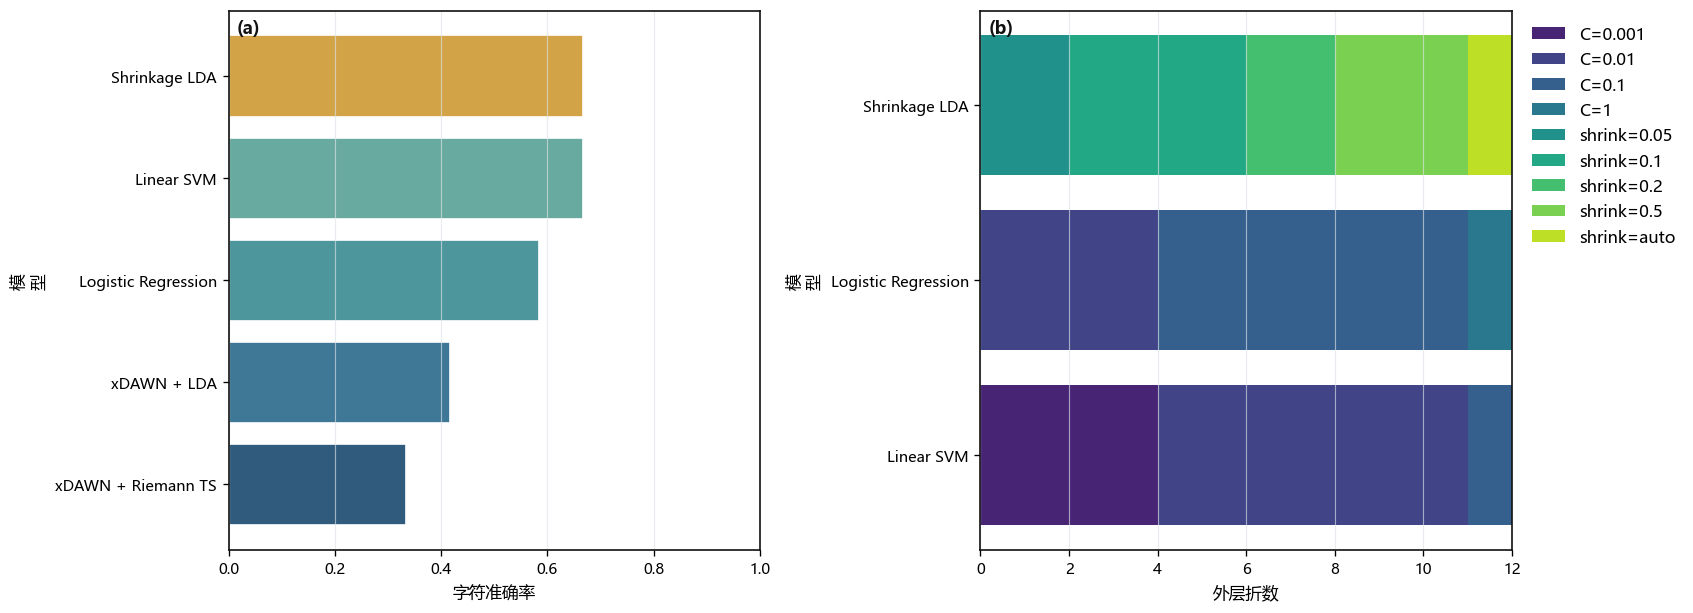

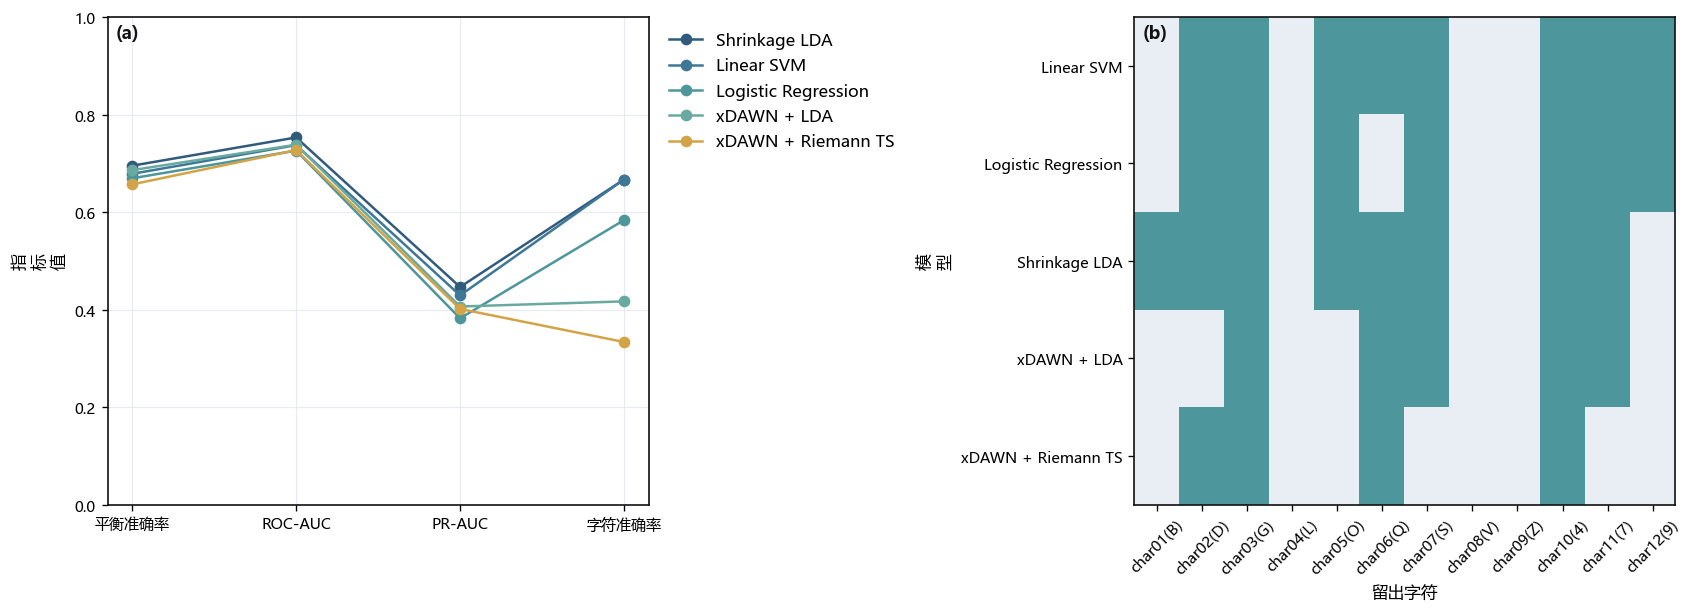

In [16]:
all_scores={**traditional_oof,**special_oof};rows=[];preds=[]
for name,sc in all_scores.items():
    mm=metric_bundle(y,sc,meta_train);dd=decode(sc,meta_train);dd["model"]=name;preds.append(dd)
    rows.append({"model":name,**mm,"character_correct":int((dd.prediction==dd.target).sum())})
results=pd.DataFrame(rows).sort_values(["character_accuracy","pr_auc","balanced_accuracy"],ascending=False).reset_index(drop=True)
predictions=pd.concat(preds,ignore_index=True);BASE_MODEL=results.iloc[0].model
HANDOFF_OUT=FLOW_ROOT/"outputs"/"05_handoff";HANDOFF_OUT.mkdir(parents=True,exist_ok=True)
results.to_csv(HANDOFF_OUT/"traditional_model_comparison_对话1.csv",index=False,encoding="utf-8-sig")
predictions.to_csv(HANDOFF_OUT/"traditional_character_predictions_对话1.csv",index=False,encoding="utf-8-sig")
display(results);print("交接基础模型:",BASE_MODEL)

fig,axes=plt.subplots(1,2,figsize=(14,5),constrained_layout=True)
r=results.iloc[::-1];axes[0].barh(r.model,r.character_accuracy,color=BAR_PALETTE[:len(r)],edgecolor="white");axes[0].set(xlabel="字符准确率",ylabel=vertical_label("模型"),xlim=(0,1));axes[0].grid(axis="x")
sel=selection_df.groupby(["family","parameter"]).size().unstack(fill_value=0)
bottom=np.zeros(len(sel))
for i,col in enumerate(sel.columns):axes[1].barh(range(len(sel)),sel[col],left=bottom,label=col,color=mpl.colormaps["viridis"]((i+1)/(len(sel.columns)+1)));bottom+=sel[col].to_numpy()
axes[1].set(yticks=range(len(sel)),yticklabels=sel.index,xlabel="外层折数",ylabel=vertical_label("模型"));axes[1].grid(axis="x");axes[1].legend(loc="upper left",bbox_to_anchor=(1.01,1),ncol=1)
frame_panels(axes);savefig(fig,"交接版_03_traditional_performance")

fig,axes=plt.subplots(1,2,figsize=(14,5),constrained_layout=True)
metrics_list=["balanced_accuracy","roc_auc","pr_auc","character_accuracy"]
for i,(_,row) in enumerate(results.iterrows()):axes[0].plot(range(4),row[metrics_list],marker="o",lw=1.5,label=row.model,color=BAR_PALETTE[i])
axes[0].set(xticks=range(4),xticklabels=["平衡准确率","ROC-AUC","PR-AUC","字符准确率"],ylabel=vertical_label("指标值"),ylim=(0,1));axes[0].grid(True);axes[0].legend(loc="upper left",bbox_to_anchor=(1.01,1),ncol=1)
pivot=predictions.assign(correct=lambda d:d.prediction==d.target).pivot(index="model",columns="sheet",values="correct").astype(int)
axes[1].imshow(pivot,cmap=mpl.colors.ListedColormap(["#E8EEF3","#4D969B"]),vmin=0,vmax=1,aspect="auto");axes[1].set(xticks=range(12),xticklabels=pivot.columns,yticks=range(len(pivot)),yticklabels=pivot.index,xlabel="留出字符",ylabel=vertical_label("模型"));axes[1].tick_params(axis="x",rotation=45)
frame_panels(axes);savefig(fig,"交接版_04_traditional_metrics")

handoff={"preprocessing":"0.5-30 Hz, 125 Hz, baseline -200-0 ms","selected_window":SELECTED,"selected_base_model":BASE_MODEL,
         "selection_rule":"character accuracy > PR-AUC > balanced accuracy","test_used":False,"results":results.to_dict(orient="records")}
with open(HANDOFF_OUT/"handoff_summary_对话1.json","w",encoding="utf-8") as f:json.dump(handoff,f,ensure_ascii=False,indent=2)

## 7. 后续同学建议接口

后续优化应继续保持trial分组：在外层训练折内优化时间分辨率、通道子集、LDA收缩、类别先验、分数校准与行列聚合；不得用未知测试答案选择方案。主数据位于`outputs/02_preprocessing/data/epochs_main_125Hz_B200_对话1.npz`，分组元数据位于对应`tables/epoch_metadata_对话1.csv`。